In [1]:
print("hello world")

hello world


In [29]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [30]:
df = pd.read_csv("Student Scores Data (1) (1).csv")

In [31]:
df

,Study_Hours,Attendance (%),Weekly_Test_Score,Final_Exam_Score
0,6.0,93,56,69
1,4.7,92,38,81
2,6.3,82,91,74
3,8.0,83,66,46
4,4.5,96,80,99
5,4.5,94,55,fifty
6,8.2,99,NaN,65
7,6.5,81,88,87
8,4.1,86,61,96
9,6.1,94,81,91


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_Hours        55 non-null     float64
 1   Attendance (%)     59 non-null     object 
 2   Weekly_Test_Score  58 non-null     object 
 3   Final_Exam_Score   59 non-null     object 
dtypes: float64(1), object(3)
memory usage: 2.0+ KB


In [33]:
df.shape

(60, 4)

In [34]:
df.isnull().sum()

Study_Hours          5
Attendance (%)       1
Weekly_Test_Score    2
Final_Exam_Score     1
dtype: int64

In [35]:
key = df.dropna(inplace= True )

In [36]:
key

In [37]:
df.isnull().sum()

Study_Hours          0
Attendance (%)       0
Weekly_Test_Score    0
Final_Exam_Score     0
dtype: int64

In [38]:
df.head()

,Study_Hours,Attendance (%),Weekly_Test_Score,Final_Exam_Score
0,6.0,93,56,69
1,4.7,92,38,81
2,6.3,82,91,74
3,8.0,83,66,46
4,4.5,96,80,99


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52 entries, 0 to 59
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_Hours        52 non-null     float64
 1   Attendance (%)     52 non-null     object 
 2   Weekly_Test_Score  52 non-null     object 
 3   Final_Exam_Score   52 non-null     object 
dtypes: float64(1), object(3)
memory usage: 2.0+ KB


In [40]:
df=df[df['Attendance (%)'].str.isnumeric()]

In [41]:
df

,Study_Hours,Attendance (%),Weekly_Test_Score,Final_Exam_Score
0,6.0,93,56,69
1,4.7,92,38,81
2,6.3,82,91,74
3,8.0,83,66,46
4,4.5,96,80,99
5,4.5,94,55,fifty
7,6.5,81,88,87
8,4.1,86,61,96
9,6.1,94,81,91
10,4.1,60,91,99


In [42]:
df=df[df['Weekly_Test_Score'].str.isnumeric()]

In [43]:
df=df[df['Final_Exam_Score'].str.isnumeric()]

In [44]:
df

,Study_Hours,Attendance (%),Weekly_Test_Score,Final_Exam_Score
0,6.0,93,56,69
1,4.7,92,38,81
2,6.3,82,91,74
3,8.0,83,66,46
4,4.5,96,80,99
7,6.5,81,88,87
8,4.1,86,61,96
9,6.1,94,81,91
10,4.1,60,91,99
11,4.1,94,87,88


In [45]:
df.head()

,Study_Hours,Attendance (%),Weekly_Test_Score,Final_Exam_Score
0,6.0,93,56,69
1,4.7,92,38,81
2,6.3,82,91,74
3,8.0,83,66,46
4,4.5,96,80,99


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 59
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_Hours        47 non-null     float64
 1   Attendance (%)     47 non-null     object 
 2   Weekly_Test_Score  47 non-null     object 
 3   Final_Exam_Score   47 non-null     object 
dtypes: float64(1), object(3)
memory usage: 1.8+ KB


In [47]:
df['Attendance (%)'] = df['Attendance (%)'].str.replace(",","").astype(int)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 59
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_Hours        47 non-null     float64
 1   Attendance (%)     47 non-null     int64  
 2   Weekly_Test_Score  47 non-null     object 
 3   Final_Exam_Score   47 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.8+ KB


In [49]:
df['Weekly_Test_Score'] = df['Weekly_Test_Score'].str.replace(",","").astype(int)

In [50]:
df['Final_Exam_Score'] = df['Final_Exam_Score'].str.replace(",","").astype(int)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 59
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_Hours        47 non-null     float64
 1   Attendance (%)     47 non-null     int64  
 2   Weekly_Test_Score  47 non-null     int64  
 3   Final_Exam_Score   47 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 1.8 KB


<Axes: xlabel='Attendance (%)', ylabel='Final_Exam_Score'>

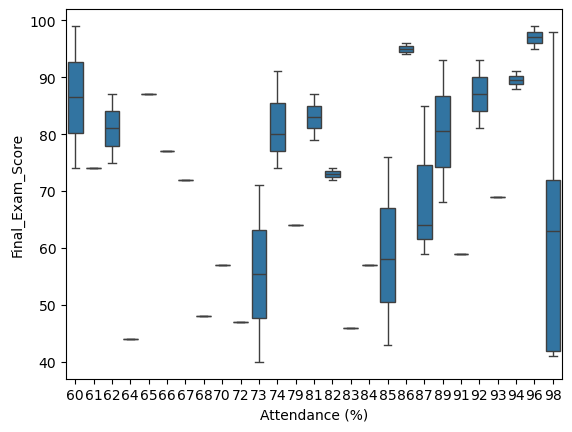

In [61]:
sns.boxplot(data=df,x='Attendance (%)',y='Final_Exam_Score')

<Axes: xlabel='Attendance (%)', ylabel='count'>

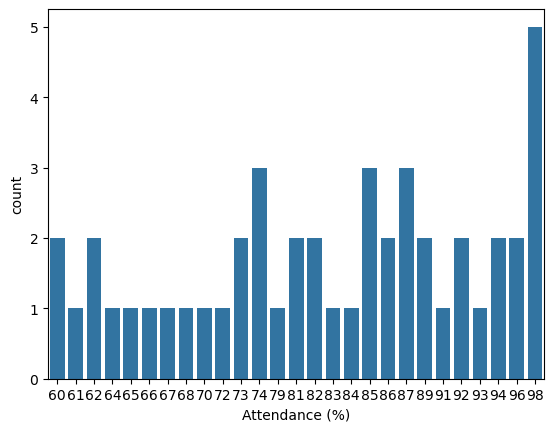

In [62]:
sns.countplot(data=df,x='Attendance (%)')

In [70]:
# Sample data (X = features, y = target)
from sklearn.model_selection import train_test_split



X_test = df[['Attendance (%)', 'Weekly_Test_Score',"Study_Hours"]]
y = df['Final_Exam_Score']
X_train, X_test, y_train, y_test = train_test_split(X_test, y, test_size=0.2, random_state=42)

In [74]:

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)


Root Mean Squared Error: 16.680483145940197


In [79]:
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)
print

Mean Squared Error: 278.238517981995
R^2 Score: -0.028380093073606893


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [80]:
import joblib
joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

In [78]:
import streamlit as st